In [1]:
# torch import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

In [2]:
# general import
from __future__ import print_function

import sys
import os
import argparse
import matplotlib.pyplot as plt

# 專案根目錄：從當前資料夾往上找到含 src/ 的目錄
ROOT = os.path.abspath('.')
while not os.path.isdir(os.path.join(ROOT, 'src')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.append(os.path.join(ROOT, 'src', 'models'))

from mnist_net import mnistNet

In [3]:
# the train function
def train(model, device, train_loader, optimizer, epoch, dry_run=False):
    model.train() # put model into train mode
    running_loss = 0.0
    n_batches = 0
    for batch_idx, (data, true_label) in enumerate(train_loader):
        data, true_label = data.to(device), true_label.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, true_label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

        if batch_idx % 50 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

            if dry_run:
                break

    return running_loss / max(n_batches, 1)  # 回傳平均訓練損失供紀錄

# the test function
def test(model, device, test_loader):
    model.eval() # put model into eval mode
    test_loss, correct = 0, 0
    with torch.no_grad():
        for data, true_label in test_loader:
            data, true_label = data.to(device), true_label.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, true_label, reduction='sum').item()
            pred_label = output.argmax(dim=1, keepdim=True)
            correct += pred_label.eq(true_label.view_as(pred_label)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    return test_loss  # 回傳平均測試損失供紀錄

In [4]:
# fetch FashionMNIST data
DATA_ROOT = os.path.join(ROOT, 'data', 'datasets')
mnist_trainset = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=True, transform=transforms.Compose([transforms.ToTensor()]))
mnist_testset = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=transforms.Compose([transforms.ToTensor()]))

train_dataloader = torch.utils.data.DataLoader(mnist_trainset, batch_size=64, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(mnist_testset, batch_size=32, shuffle=False)

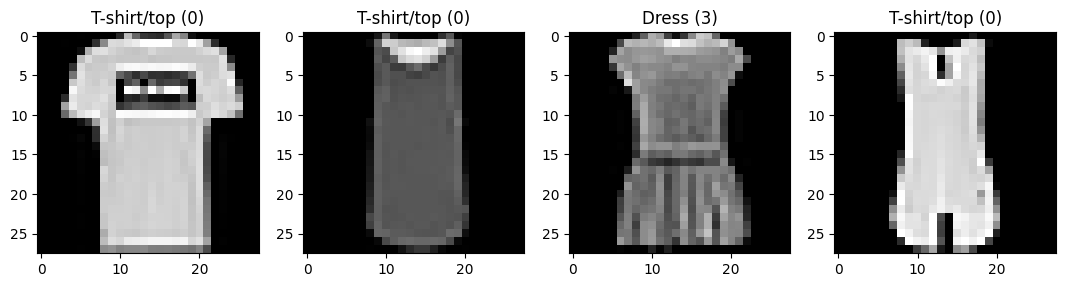

In [5]:
# visualize some images from the training set
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig = plt.figure(figsize=(20, 10))
for i in range(1, 5):
    img = mnist_trainset[i][0]
    img = img.view(28, -1) # get rid of the third dimension
    label = mnist_trainset[i][1]
    fig.add_subplot(1, 6, i)
    plt.title(f"{CLASS_NAMES[label]} ({label})")  # 顯示類別名稱與代號
    plt.imshow(img, cmap="gray")  # 指定灰階色盤，否則預設 viridis 會變彩色
plt.show()

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rate = 0.001
step_size = 10
num_epochs = 30
save_model = True
dry_run = False # 🌟 True:吃權重, False:訓練！

# 🌟 設定訓練是否開啟 Dropout？ (True = 有防禦, False = 無防禦)
ENABLE_DROPOUT = False

model = mnistNet(use_dropout=ENABLE_DROPOUT).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = StepLR(optimizer, step_size=step_size)

# 1. 初始化紀錄列表
train_loss_history = []
test_loss_history = []


for epoch in range(1, num_epochs + 1):
    train_avg_loss = train(model, device, train_dataloader, optimizer, epoch, dry_run)
    test_avg_loss = test(model, device, test_dataloader)
    # scheduler.step()

    # 存入紀錄
    train_loss_history.append(train_avg_loss)
    test_loss_history.append(test_avg_loss)

if save_model:
    # 🌟 讓程式自己決定優雅的專屬檔名
    if ENABLE_DROPOUT:
        save_name = "fashion_mnist_cnn_with_dropout.pt"
    else:
        save_name = "fashion_mnist_cnn_no_dropout.pt"

    # 🌟 存到專案的 checkpoints 資料夾
    save_dir = os.path.join(ROOT, "checkpoints")
    os.makedirs(save_dir, exist_ok=True)

    # 組合路徑與檔名
    save_path = os.path.join(save_dir, save_name)
    torch.save(model.state_dict(), save_path)

    # 訓練結束後，印出貼心提示
    print(f"✨ 訓練完成！模型已儲存至：{save_path}")

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.309041
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.764189
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.464972
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.462806
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.503781
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.311856
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.594796
Train Epoch: 1 [22400/60000 (37%)]	Loss: 0.229788
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.337070
Train Epoch: 1 [28800/60000 (48%)]	Loss: 0.301327
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.230705
Train Epoch: 1 [35200/60000 (59%)]	Loss: 0.385735
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.348542
Train Epoch: 1 [41600/60000 (69%)]	Loss: 0.460619
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.275320
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.380492
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.292525
Train Epoch: 1 [54400/60000 (91%)]	Loss: 0.240485
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.251602

Test set: Average loss: 0.3274, Accuracy: 8786/10000 (88%)